## Problem Statement
This notebook aims to reconstruct an image from undersampled k-space data using a sparse representation in a Gaussian kernel basis. The primary goal is to minimize the difference between the observed undersampled k-space and the k-space of the reconstructed image, effectively recovering the image information lost due to undersampling.

tcia_utils nbia is the interface to the cancer imaging archive so theres available datasets we can use

In [ ]:

!pip install tcia_utils pydicom torch matplotlib numpy torchmetrics
import torch
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import os
from tcia_utils import nbia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 14.6 MB/s eta 0:00:00


In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
import shutil

data = nbia.getSeries(collection="UPENN-GBM")
if data is None:
    raise RuntimeError("UPENN-GBM returned no data.")
print(f"'UPENN-GBM' returned {len(data)} series")

# reset to avoid adding images after re-running
if os.path.exists("./brain_mri"):
    shutil.rmtree("./brain_mri")
os.makedirs("./brain_mri")

nbia.downloadSeries(data[2:3], number=1, path="./brain_mri")

for i, s in enumerate(data[:10]):
    print(f"Index {i}: {s.get('SeriesDescription')} | Images: {s.get('ImageCount')} | Size: {s.get('')}")

# get middle slice
dcm_files = []
for root, dirs, files in os.walk("./brain_mri"):
    for f in files:
        if f.lower().endswith(".dcm"):
            dcm_files.append(os.path.join(root, f))

datasets = [pydicom.dcmread(f) for f in dcm_files]
datasets.sort(key=lambda ds: ds.InstanceNumber)

mid = len(datasets) // 2
ds = datasets[mid]
pixel_data = ds.pixel_array.astype(np.float32)

if hasattr(ds, 'RescaleSlope'):
    pixel_data = pixel_data * float(ds.RescaleSlope) + float(ds.RescaleIntercept)

print(f"Loaded slice {mid+1}/{len(datasets)}, shape: {pixel_data.shape}")


'UPENN-GBM' returned 3680 series
Index 0: AXIAL 3D GAD: Processed_CaPTk | Images: 120 | Size: None
Index 1: AX FLAIR: Processed_CaPTk | Images: 32 | Size: None
Index 2: AX T1 PRE : Processed_CaPTk | Images: 32 | Size: None
Index 3: AX T2 : Processed_CaPTk | Images: 32 | Size: None
Index 4: AX T2 : Processed_CaPTk | Images: 32 | Size: None
Index 5: AX T1 MPRAGE ISOTROPIC: Processed_CaPTk | Images: 192 | Size: None
Index 6: AXIAL FLAIR : Processed_CaPTk | Images: 60 | Size: None
Index 7: AX T1 PRE : Processed_CaPTk | Images: 32 | Size: None
Index 8: ep2d_perf 12 CC BOLUS | Images: 900 | Size: None
Index 9: ep2d_perf 12 CC BOLUS | Images: 900 | Size: None
Loaded slice 17/32, shape: (256, 256)


## Data Requirements
*   **Input Data:** The model expects a 2D Image
*   **Preprocessing:** Data is normalized to a [0, 1] range after clipping outliers and resized to a fixed 256x256 resolution. This preprocessed 2D image serves as the target_image for reconstruction.

Trying to find an available mri collection and downloads a series, a full stack of 2d slices
sorts them by slice order and take the middle scan

Normalize and resize  so that gradient descent works faster:

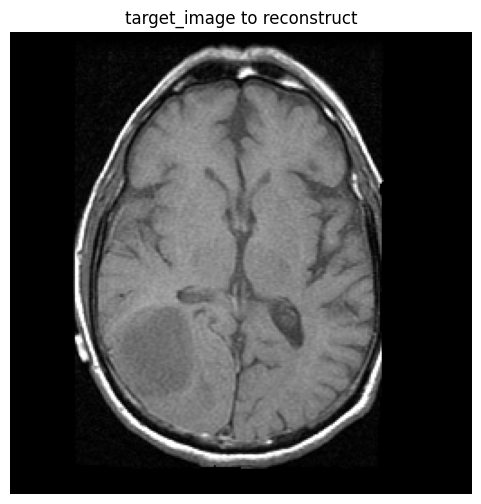

In [ ]:

# Normalize to [0, 1]
# Clip  1st and 99 percentile
p_low, p_high = np.percentile(pixel_data, (1, 99))
pixel_data = np.clip(pixel_data, p_low, p_high)
pixel_data = (pixel_data - p_low) / (p_high - p_low)

# Resize to 256x256 using torch interpolate
target_image = torch.tensor(pixel_data).unsqueeze(0).unsqueeze(0)  # -> [1, 1, H, W]
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear')
target_image = target_image.squeeze()  # -> [256, 256]

plt.figure(figsize=(6, 6))
plt.imshow(target_image.numpy(), cmap='gray')
plt.title("target_image to reconstruct")
plt.axis('off')
plt.show()

In [ ]:
def tv_loss(x, eps=1e-6):
    dx = x[1:, :] - x[:-1, :]      # [255, 256]
    dy = x[:, 1:] - x[:, :-1]      # [256, 255]

    dx = dx[:, :-1]                # → [255, 255]
    dy = dy[:-1, :]                # → [255, 255]

    return torch.mean(torch.sqrt(dx**2 + dy**2 + eps))

In [ ]:
def create_kernel_basis(grid_size=256, num_kernels=16384, sigma=1.5):
    x = torch.linspace(0, grid_size, grid_size)
    y = torch.linspace(0, grid_size, grid_size)
    grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

    # centers_x = torch.randint(0, grid_size, (num_kernels,))
    # centers_y = torch.randint(0, grid_size, (num_kernels,))
    coords = torch.linspace(0, grid_size-1, int(np.sqrt(num_kernels)))
    centers_x, centers_y = torch.meshgrid(coords, coords, indexing='ij')
    centers_x = centers_x.flatten()
    centers_y = centers_y.flatten()


    basis = []
    for i in range(num_kernels):
        dist_sq = (grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2
        # Laplacian kernel: exp(-distance / sigma)
        kernel = torch.exp(-torch.sqrt(dist_sq) / sigma)
        basis.append(kernel.flatten())

    return torch.stack(basis).T  # [65536 x num_kernels]

Phi = create_kernel_basis()
print(f"Phi shape: {Phi.shape}")

Phi shape: torch.Size([65536, 16384])


In [ ]:

target_image = target_image.to(device)
# Use fftshift to move the low frequencies to the center before masking
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))

mask = torch.zeros_like(k_full, dtype=torch.complex64)
center_h, center_w = k_full.shape[-2] // 2, k_full.shape[-1] // 2
dist = 128
mask[center_h - dist : center_h + dist, center_w - dist : center_w + dist] = 1

y_obs = k_full * mask

print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    """Applies 2D inverse Fast Fourier Transform and returns the real part."""
    return torch.fft.ifft2(k_space_data).real

print("ifft2 function defined.")

k_full shape: torch.Size([256, 256])
mask shape: torch.Size([256, 256])
y_obs shape: torch.Size([256, 256])
ifft2 function defined.


In [ ]:

num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).detach().requires_grad_(True)
learning_rate = .01
optimizer = torch.optim.Adam([c], lr=learning_rate)

print(f"Initialized coefficients 'c' with shape: {c.shape}")
print("Optimizer (Adam) initialized.")


Initialized coefficients 'c' with shape: torch.Size([16384])
Optimizer (Adam) initialized.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move everything first
Phi = Phi.to(device).float()
target_image = target_image.to(device)
mask = mask.to(device)

# Recompute k-space on device
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
y_obs = k_full * mask

# Initialize c ON DEVICE
num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).requires_grad_(True)

# Create optimizer AFTER moving c
optimizer = torch.optim.Adam([c], lr=0.01)

Using device: cuda


In [ ]:

loss_history = []
num_epocs = 10000
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=2500, gamma=0.92
)
for epoch in range(num_epocs):
    optimizer.zero_grad()

    #Generate image from basis functions
    x_recon = (Phi @ c).reshape(256, 256)

   #ransform reconstruction to k-space
    k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))

   #apply the same mask to the reconstruction
    y_recon = k_recon * mask

    # loss = torch.mean(torch.abs(y_recon - y_obs)**2)
    lambda_tv = 1e-4  # start small
    data_loss = torch.mean(torch.abs(y_recon - y_obs)**2)
    tv = tv_loss(x_recon)
    loss = data_loss + lambda_tv * tv
    # if (epoch + 1) % 100 == 0:
    #     print(f"Epoch {epoch + 1}/{num_epocs}, Loss: {loss.item():.4f}")
    if (epoch + 1) % 100 == 0:
      print(f"Epoch {epoch + 1}/{num_epocs}, "
      f"Data: {data_loss.item():.4f}, "
      f"TV: {tv.item():.4f}")
    loss.backward()
    optimizer.step()
    scheduler.step()
    loss_history.append(loss.item())

Epoch 100/10000, Data: 161.6900, TV: 0.0388
Epoch 200/10000, Data: 112.7458, TV: 0.0425
Epoch 300/10000, Data: 99.9350, TV: 0.0445
Epoch 400/10000, Data: 96.0008, TV: 0.0455
Epoch 500/10000, Data: 94.7611, TV: 0.0460
Epoch 600/10000, Data: 94.3733, TV: 0.0462
Epoch 700/10000, Data: 94.2635, TV: 0.0463
Epoch 800/10000, Data: 94.2421, TV: 0.0464
Epoch 900/10000, Data: 94.2034, TV: 0.0464
Epoch 1000/10000, Data: 94.2094, TV: 0.0464
Epoch 1100/10000, Data: 94.2215, TV: 0.0464
Epoch 1200/10000, Data: 94.2171, TV: 0.0464
Epoch 1300/10000, Data: 94.2074, TV: 0.0464
Epoch 1400/10000, Data: 94.2164, TV: 0.0464
Epoch 1500/10000, Data: 94.2197, TV: 0.0464
Epoch 1600/10000, Data: 94.1997, TV: 0.0464
Epoch 1700/10000, Data: 94.2375, TV: 0.0464
Epoch 1800/10000, Data: 94.1984, TV: 0.0464
Epoch 1900/10000, Data: 94.2466, TV: 0.0464
Epoch 2000/10000, Data: 94.2092, TV: 0.0464
Epoch 2100/10000, Data: 94.2047, TV: 0.0464
Epoch 2200/10000, Data: 94.2246, TV: 0.0464
Epoch 2300/10000, Data: 94.2842, TV: 0.

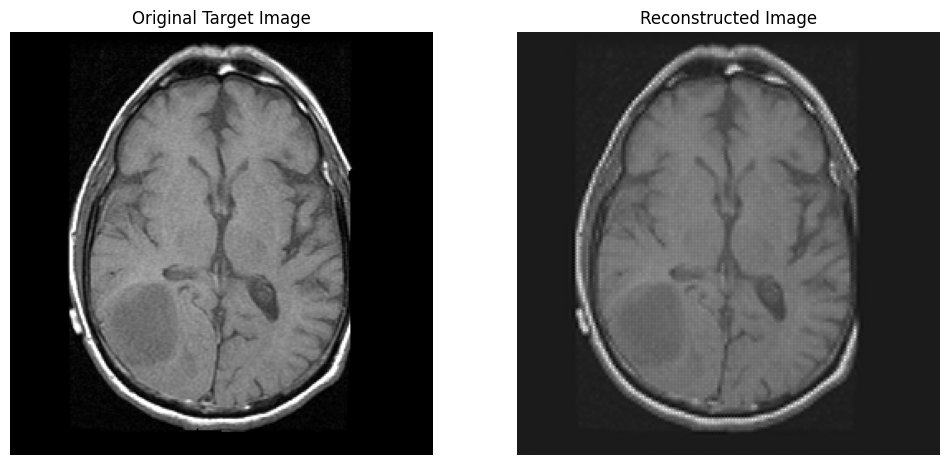

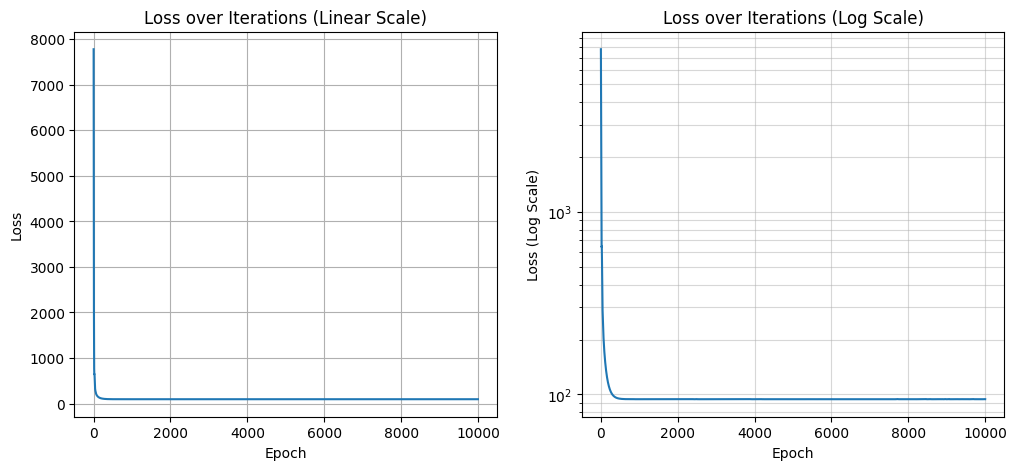

In [ ]:
import matplotlib.pyplot as plt

final_x_recon = (Phi @ c).reshape(256, 256)
reconstructed_image = final_x_recon.cpu().detach().numpy()
target_image_np = target_image.cpu().detach().numpy()

#Visual Comparison: Original vs. Reconstructed
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(target_image_np, cmap='gray')
plt.title('Original Target Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()

#Optimization Performance: Linear and Log Loss Plots
plt.figure(figsize=(12, 5))

# Standard Linear Plot
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Iterations (Linear Scale)')
plt.grid(True)

# Log Scale Plot
plt.subplot(1, 2, 2)
plt.semilogy(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Loss over Iterations (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

## Zero-Filled FFT Baseline Reconstruction

Zero-Filled FFT MSE: 0.000000
Zero-Filled FFT PSNR: 320.09 dB


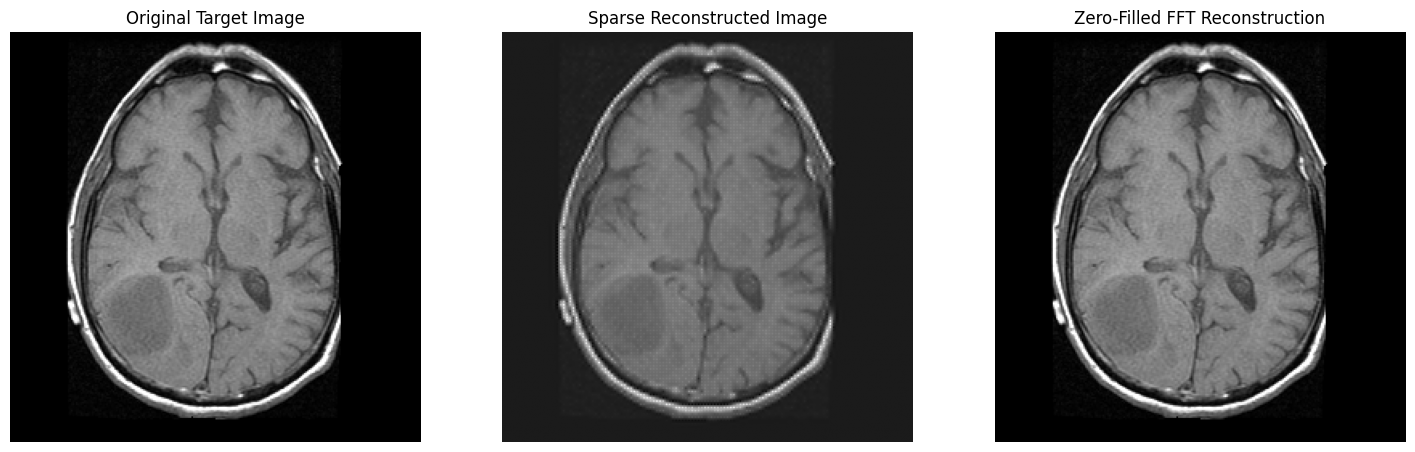


--- PSNR Comparison ---
Sparse Reconstruction PSNR: 28.42 dB
Zero-Filled FFT PSNR: 320.09 dB

--- MSE Comparison ---
Sparse Reconstruction MSE: 0.001438
Zero-Filled FFT MSE: 0.000000


In [ ]:
import torch.nn.functional as F
# Perform zero-filled IFFT reconstruction
y_zero_filled = ifft2(torch.fft.ifftshift(y_obs))
x_zf = y_zero_filled.abs()

# Calculate MSE and PSNR for the zero-filled reconstruction
mse_zero_filled = F.mse_loss(y_zero_filled.flatten(), target_image.flatten())
psnr_zero_filled = 10 * torch.log10(1.0 / mse_zero_filled)

print(f"Zero-Filled FFT MSE: {mse_zero_filled.item():.6f}")
print(f"Zero-Filled FFT PSNR: {psnr_zero_filled.item():.2f} dB")

# Visual Comparison: Original vs. Reconstructed vs. Zero-Filled
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(target_image_np, cmap='gray')
plt.title('Original Target Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Sparse Reconstructed Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(y_zero_filled.cpu().detach().numpy(), cmap='gray')
plt.title('Zero-Filled FFT Reconstruction')
plt.axis('off')

plt.show()

mse = F.mse_loss(final_x_recon.flatten(), target_image.flatten())
psnr = 10 * torch.log10(1.0 / mse)

print("\n--- PSNR Comparison ---")
print(f"Sparse Reconstruction PSNR: {psnr.item():.2f} dB")
print(f"Zero-Filled FFT PSNR: {psnr_zero_filled.item():.2f} dB")

print("\n--- MSE Comparison ---")
print(f"Sparse Reconstruction MSE: {mse.item():.6f}")
print(f"Zero-Filled FFT MSE: {mse_zero_filled.item():.6f}")

## Success Metrics
The performance of the image reconstruction is evaluated using:
*   **Mean Squared Error (MSE):** Measures the average squared difference between the reconstructed image and the original target image.
*   **Peak Signal-to-Noise Ratio (PSNR):** A common metric for image quality, providing a quantitative measure of reconstruction fidelity. Higher PSNR values indicate better reconstruction quality.

In [ ]:
mse = F.mse_loss(final_x_recon.flatten(), target_image.flatten())
psnr = 10 * torch.log10(1.0 / mse)
print(f"MSE: {mse.item():.6f}")
print(f"PSNR: {psnr.item():.2f} dB")

MSE: 0.001572
PSNR: 28.04 dB


## Resource Monitoring


*   System Ram - 7.8/12.7 GB
*   GPU Ram - 4.2/15.0 GB

*   Disk - 38.8/112.6 GB





## Known Limitations
*   **Basis Function Choice:** The current implementation uses fixed-size Gaussian kernels. The choice of sigma and num_kernels is empirical and may not be optimal for all image types or reconstruction tasks.
*   **Undersampling Pattern:** The mask for k-space undersampling is a simple central region. More advanced undersampling patterns are not explored.
*   **Computational Cost:** For very large images or a significantly higher number of basis functions, the matrix multiplication Phi @ c can become computationally intensive.
*   **Lack of Regularization:** The current objective function only minimizes the k-space error. Incorporating regularization  could improve reconstruction quality and noise suppression.

## Neural Network Approach
*   **Explore different basis functions:** Investigate other sparse representations beyond Gaussian kernels.
*   **Implement image-domain regularization:** Add Total Variation (TV) or other regularization terms to the loss function to improve reconstruction quality and noise robustness.
*   **Dynamic mask generation:** Implement methods to generate more complex or adaptive k-space undersampling masks.
*   **Hyperparameter tuning:** Systematically tune parameters like sigma, num_kernels, learning_rate, and regularization weights.
*   **Quantitative evaluation:** Perform reconstructions on a larger dataset and compare results with other MRI reconstruction methods.

In [ ]:
def dicom_to_target_tensor(ds, out_size=(256,256)):
  arr = ds.pixel_array.astype(np.float32)

  if hasattr(ds, "RescaleSlope"):
    slope = float(ds.RescaleSlope)
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept

  p_low, p_high = np.percentile(arr, (1, 99))
  arr = np.clip(arr, p_low, p_high)
  arr = (arr - p_low) / (p_high - p_low + 1e-12)

  t = torch.tensor(arr).unsqueeze(0).unsqueeze(0)
  t = F.interpolate(t, size=out_size, mode="bilinear", align_corners=False)
  return t.squeeze(0).float()

In [ ]:
@torch.no_grad()
def compute_psnr(pred, target, data_range=1.0, eps=1e-12):
  mse = F.mse_loss(pred, target)
  return 10.0 * torch.log10((data_range ** 2) / (mse + eps))

In [ ]:
target_list = []
for i, ds in enumerate(datasets):
  target_list.append(dicom_to_target_tensor(ds))

target_images = torch.stack(target_list, dim=0).to(device)
print(target_images.shape)
print(target_images.dtype)

torch.Size([32, 1, 256, 256])
torch.float32


In [ ]:
N, C, H, W = target_images.shape

dist = 32
k0 = torch.fft.fftshift(torch.fft.fft2(target_images[0, 0]))
mask_multi = torch.zeros_like(k0, dtype=torch.complex64)
center_h, center_w = H // 2, W // 2
mask_multi[center_h - dist:center_h + dist, center_w - dist:center_w + dist] = 1
mask_multi = mask_multi.to(device)

In [ ]:
undersampled_list = []
for i in range(N):
  img = target_images[i, 0]
  k_full = torch.fft.fftshift(torch.fft.fft2(img))
  y_obs = k_full * mask_multi
  us = torch.fft.ifft2(torch.fft.ifftshift(y_obs)).real
  us = torch.clamp(us, 0.0, 1.0)
  undersampled_list.append(us.unsqueeze(0))

undersampled_images = torch.stack(undersampled_list, dim=0).to(device)
print(f"undersampled images: {undersampled_images.shape}, {undersampled_images.dtype}")

undersampled images: torch.Size([32, 1, 256, 256]), torch.float32


In [ ]:
test_idx = mid+1

x_test = undersampled_images[test_idx:test_idx+1]
y_test = target_images[test_idx:test_idx+1]

x_train = torch.cat([undersampled_images[:test_idx], undersampled_images[test_idx+1:]], dim=0)
y_train = torch.cat([target_images[:test_idx], target_images[test_idx+1:]], dim=0)

print(f"train: {x_train.shape}, {y_train.shape}")
print(f"test: {x_test.shape}, {y_test.shape}")

baseline_psnr = compute_psnr(x_test, y_test).item()
print(f"Baseline psnr held-out slice 77: {baseline_psnr:.4f} dB")

train: torch.Size([31, 1, 256, 256]), torch.Size([31, 1, 256, 256])
test: torch.Size([1, 1, 256, 256]), torch.Size([1, 1, 256, 256])
Baseline psnr held-out slice 77: 24.1241 dB


In [ ]:
from torch.utils.data import Dataset, DataLoader

class PairDataset(Dataset):
  def __init__(self, x, y):
    self.x = x.float()
    self.y = y.float()

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, i):
    return self.x[i], self.y[i]

train_loader = DataLoader(PairDataset(x_train, y_train), batch_size=8, shuffle=True)

In [ ]:
import torch.nn as nn

class ResidualCNN(nn.Module):
  def __init__(self, ch=64):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, 1, 3, padding=1),
    )

  def forward(self, x):
    return x + self.net(x)

model = ResidualCNN(ch=64).to(device)

In [ ]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.L1Loss()

epochs = 15
for ep in range(1, epochs + 1):
  model.train()
  running = 0.0

  for xb, yb in train_loader:
    xb = xb.to(device)
    yb = yb.to(device)

    opt.zero_grad(set_to_none=True)
    pred = model(xb)
    loss = loss_fn(pred, yb)
    loss.backward()
    opt.step()

    running += loss.item() * xb.size(0)

  model.eval()
  with torch.no_grad():
    pred_test = torch.clamp(model(x_test), 0.0, 1.0)
    test_psnr = compute_psnr(pred_test, y_test).item()

  print(f"Epoch {ep:02d} | train_loss={running/len(x_train):.4f} | test_PSNR={test_psnr:.4f} dB (improvement: {test_psnr - baseline_psnr:.4f})")

Epoch 01 | train_loss=0.0302 | test_PSNR=24.1321 dB (improvement: 0.0080)
Epoch 02 | train_loss=0.0260 | test_PSNR=24.1302 dB (improvement: 0.0060)
Epoch 03 | train_loss=0.0250 | test_PSNR=24.1279 dB (improvement: 0.0037)
Epoch 04 | train_loss=0.0247 | test_PSNR=24.1269 dB (improvement: 0.0028)
Epoch 05 | train_loss=0.0246 | test_PSNR=24.1546 dB (improvement: 0.0305)
Epoch 06 | train_loss=0.0244 | test_PSNR=24.1467 dB (improvement: 0.0226)
Epoch 07 | train_loss=0.0241 | test_PSNR=24.1508 dB (improvement: 0.0267)
Epoch 08 | train_loss=0.0240 | test_PSNR=24.1571 dB (improvement: 0.0330)
Epoch 09 | train_loss=0.0240 | test_PSNR=24.1660 dB (improvement: 0.0419)
Epoch 10 | train_loss=0.0240 | test_PSNR=24.1763 dB (improvement: 0.0521)
Epoch 11 | train_loss=0.0240 | test_PSNR=24.1722 dB (improvement: 0.0481)
Epoch 12 | train_loss=0.0243 | test_PSNR=24.1988 dB (improvement: 0.0747)
Epoch 13 | train_loss=0.0243 | test_PSNR=24.1817 dB (improvement: 0.0576)
Epoch 14 | train_loss=0.0244 | test_PS

In [ ]:
model.eval()
with torch.no_grad():
  pred_test = torch.clamp(model(x_test), 0.0, 1.0)

nn_psnr = compute_psnr(pred_test, y_test).item()
baseline_psnr = compute_psnr(x_test, y_test).item()

print(f"Baseline PSNR (undersampled): {baseline_psnr:.4f} dB")
print(f"NN PSNR: {nn_psnr:.4f} dB")
print(f"Improvement: {nn_psnr - baseline_psnr:.4f} dB")

gt_img = y_test[0,0].detach().cpu().numpy()
us_img = x_test[0,0].detach().cpu().numpy()
nn_img = pred_test[0,0].detach().cpu().numpy()

Baseline PSNR (undersampled): 24.1241 dB
NN PSNR: 24.1978 dB
Improvement: 0.0736 dB


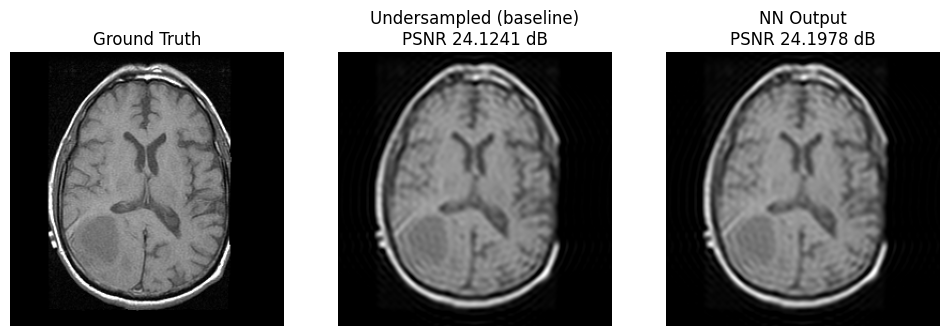

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(us_img, cmap="gray")
plt.title(f"Undersampled (baseline)\nPSNR {baseline_psnr:.4f} dB")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(nn_img, cmap="gray")
plt.title(f"NN Output\nPSNR {nn_psnr:.4f} dB")
plt.axis("off")

plt.show()

# Residual Corrector NNs
* Using Gaussian kernel reconstruction as input to neural network.
* Let neural network fill in gaps from Gaussian reconstruction, while requiring it not to change measured values from k-space.
* Change NN structure from ReLU to U-Net architecture (more common for medical applications)
* Measure accuracy via MSE, PSNR, and SSIM

In [ ]:
# Using a U-Net Architecture with skip connections

# changing nn from basic ReLU to U-Net architecture (using BatchNorm2d)
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return x + self.conv(x)

# outputs 'residual' between Gaussian reconstruction and target image
class MRICorrector(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        self.res_layers = nn.Sequential(
            *[ResidualBlock(64) for _ in range(5)]
        )
        self.final = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x):
        # x shape: (Batch, 2, H, W)
        residual = self.final(self.res_layers(self.initial(x)))
        return x + residual

# define new model
model2 = MRICorrector().to(device)

In [ ]:
import torch.fft as fft

def ensure_tensor(data, device):
    if isinstance(data, np.ndarray):
        return torch.from_numpy(data).float().to(device)
    elif torch.is_tensor(data):
        return data.float().to(device)
    else:
        raise TypeError("Format not recognized. Use NumPy or Tensor.")

def train_real_mri_corrector(model, img_gt, img_gauss, mask, epochs=500):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    input_t = ensure_tensor(img_gauss, device).reshape(1, 1, H, W)
    target_t = ensure_tensor(img_gt, device).reshape(1, 1, H, W)
    mask_t = ensure_tensor(mask, device).reshape(H, W)

    k_gt = torch.fft.fft2(target_t)

    for epoch in range(epochs):
        optimizer.zero_grad()

        residual = model(input_t)
        refined_img = input_t + residual

        k_pred = torch.fft.fft2(refined_img)
        k_final = (mask_t * k_gt) + ((1 - mask_t) * k_pred)

        output_img = torch.fft.ifft2(k_final).abs()

        # Loss (MSE)
        loss = torch.nn.functional.mse_loss(output_img, target_t)
        loss.backward()
        optimizer.step()

        # PSNR
        psnr = compute_psnr(output_img, target_t)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item()} | PSNR: {psnr}")

    return output_img.detach().cpu().squeeze().numpy()

target image size: torch.Size([256, 256])
Gaussian image size: (256, 256)
Mask size: torch.Size([256, 256])
___


/tmp/ipykernel_185/798948624.py:7: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  return data.float().to(device)


Epoch 0 | Loss: 4.3310306546923225e-15 | PSNR: 119.98123168945312
Epoch 100 | Loss: 4.3310306546923225e-15 | PSNR: 119.98123168945312
Epoch 200 | Loss: 4.3310306546923225e-15 | PSNR: 119.98123168945312
Epoch 300 | Loss: 4.3310306546923225e-15 | PSNR: 119.98123168945312
Epoch 400 | Loss: 4.3310306546923225e-15 | PSNR: 119.98123168945312


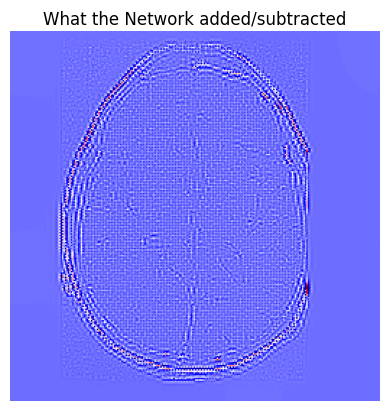

In [ ]:
# sanity checks
print(f"target image size: {target_image.shape}")
print(f"Gaussian image size: {reconstructed_image.shape}")
print(f"Mask size: {mask.shape}")
print("___")

nn_gaus_img = train_real_mri_corrector(model2, target_image, reconstructed_image, mask)

# plotting
correction = nn_gaus_img - reconstructed_image
plt.imshow(correction, cmap='seismic') # Seismic shows positive/negative changes
plt.title("What the Network added/subtracted")
plt.axis('off')
plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def evaluate_reconstruction(gt, initial, refined):
    """
    gt: Ground Truth (Original Image)
    initial: Gaussian Reconstructed Image
    refined: Neural Network Output
    """
    # Ensure all are 2D numpy arrays and normalized to [0, 1]
    def normalize(img):
        return (img - img.min()) / (img.max() - img.min() + 1e-8)

    gt = normalize(gt)
    initial = normalize(initial)
    refined = normalize(refined)

    # Calculate Metrics
    metrics = {
        "Initial": {
            "MSE": np.mean((gt - initial)**2),
            "PSNR": psnr(gt, initial, data_range=1.0),
            "SSIM": ssim(gt, initial, data_range=1.0)
        },
        "Refined": {
            "MSE": np.mean((gt - refined)**2),
            "PSNR": psnr(gt, refined, data_range=1.0),
            "SSIM": ssim(gt, refined, data_range=1.0)
        }
    }

    # Print Results
    print(f"{'Metric':<10} | {'Gaussian':<12} | {'Neural':<12} | {'Improvement'}")
    print("-" * 55)
    for m in ["MSE", "PSNR", "SSIM"]:
        init_val = metrics["Initial"][m]
        ref_val = metrics["Refined"][m]
        diff = ref_val - init_val if m != "MSE" else init_val - ref_val
        print(f"{m:<10} | {init_val:.6f} | {ref_val:.6f} | {diff:+.6f}")

    return metrics

In [ ]:
def plot_results(gt, initial, refined):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Error maps
    error_initial = np.abs(gt - initial)
    error_refined = np.abs(gt - refined)

    axes[0].imshow(initial, cmap='gray')
    axes[0].set_title("Gaussian Input")
    axes[0].axis('off')

    axes[1].imshow(refined, cmap='gray')
    axes[1].set_title("Neural Refined")
    axes[1].axis('off')

    # High intensity = high error.
    im = axes[2].imshow(error_initial - error_refined, cmap='seismic')
    axes[2].set_title("Error Reduction (Blue = Better)")
    plt.colorbar(im, ax=axes[2])
    plt.axis("off")

    plt.show()

In [ ]:
#print(type(reconstructed_image))
#print(type(target_image))

# uncomment this line the first time you run this cell
#target_image = target_image.detach().cpu().numpy()

evaluate_reconstruction(target_image, reconstructed_image, nn_gaus_img)

Metric     | Gaussian     | Neural       | Improvement
-------------------------------------------------------
MSE        | 0.009208 | 0.000000 | +0.009208
PSNR       | 20.358528 | 141.220190 | +120.861662
SSIM       | 0.474748 | 1.000000 | +0.525252


{'Initial': {'MSE': np.float64(0.009207616044499012),
  'PSNR': np.float64(20.358527989820917),
  'SSIM': np.float64(0.4747479074889716)},
 'Refined': {'MSE': np.float64(7.550591780794996e-15),
  'PSNR': np.float64(141.22019009024854),
  'SSIM': np.float64(0.999999999989911)}}

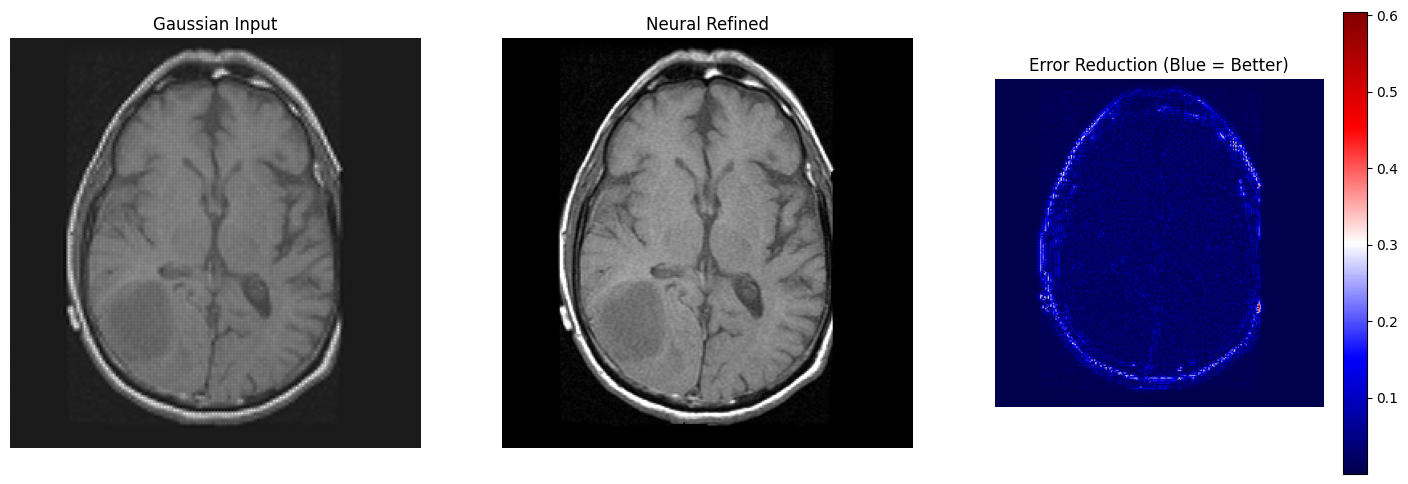

In [ ]:
plot_results(target_image, reconstructed_image, nn_gaus_img)

SRCNN
# 3-layer SRCNN following Dong(2015)
    # Layer 1 — Patch extraction & representation: conv 9x9, 64 filters
    # Layer 2 — Non-linear mapping:               conv 5x5, 32 filters
    # Layer 3 — Reconstruction:                   conv 5x5,  1 filter
    # ReLU after layers 1 and 2; no activation after layer 3.
    # Input/output are single-channel (grayscale) images in [0, 1].

In [ ]:
import torch.nn as nn

class SRCNN(nn.Module):

    # 3-layer SRCNN following Dong(2015)
    # Layer 1 — Patch extraction & representation: conv 9x9, 64 filters
    # Layer 2 — Non-linear mapping:               conv 5x5, 32 filters
    # Layer 3 — Reconstruction:                   conv 5x5,  1 filter
    # ReLU after layers 1 and 2; no activation after layer 3.
    # Input/output are single-channel (grayscale) images in [0, 1].

    def __init__(self):
        super(SRCNN, self).__init__()
        self.layer1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.layer2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.layer3 = nn.Conv2d(32,  1, kernel_size=5, padding=2)
        self.relu   = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x


srcnn = SRCNN().to(device)
print(srcnn)
total_params = sum(p.numel() for p in srcnn.parameters())
print(f"Total trainable parameters: {total_params:,}")

SRCNN(
  (layer1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (layer2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (layer3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)
Total trainable parameters: 57,281


In [ ]:
x_recon_detached = final_x_recon.detach().clamp(0, 1)   # [256, 256]

# Normalise to [0, 1]
x_min, x_max = x_recon_detached.min(), x_recon_detached.max()
x_recon_norm  = (x_recon_detached - x_min) / (x_max - x_min + 1e-8)

if isinstance(target_image, np.ndarray):
    target_image = torch.tensor(target_image).float().to(device)

lr_input  = x_recon_norm.unsqueeze(0).unsqueeze(0).float()
hr_target = target_image.clamp(0, 1).unsqueeze(0).unsqueeze(0).float()

print(f"LR input  shape : {lr_input.shape}")
print(f"HR target shape : {hr_target.shape}")

LR input  shape : torch.Size([1, 1, 256, 256])
HR target shape : torch.Size([1, 1, 256, 256])


In [ ]:

srcnn_optimizer = torch.optim.Adam([
    {'params': srcnn.layer1.parameters(), 'lr': 1e-4},
    {'params': srcnn.layer2.parameters(), 'lr': 1e-4},
    {'params': srcnn.layer3.parameters(), 'lr': 1e-5},
])
mse_loss = nn.MSELoss()

num_srcnn_epochs = 20000
srcnn_loss_history = []

srcnn.train()
for epoch in range(num_srcnn_epochs):
    srcnn_optimizer.zero_grad()

    sr_output = srcnn(lr_input)
    loss      = mse_loss(sr_output, hr_target)

    loss.backward()
    srcnn_optimizer.step()
    srcnn_loss_history.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{num_srcnn_epochs}  MSE Loss: {loss.item():.6f}")

Epoch 200/20000  MSE Loss: 0.000922
Epoch 400/20000  MSE Loss: 0.000687
Epoch 600/20000  MSE Loss: 0.000615
Epoch 800/20000  MSE Loss: 0.000568
Epoch 1000/20000  MSE Loss: 0.000533
Epoch 1200/20000  MSE Loss: 0.000504
Epoch 1400/20000  MSE Loss: 0.000479
Epoch 1600/20000  MSE Loss: 0.000458
Epoch 1800/20000  MSE Loss: 0.000439
Epoch 2000/20000  MSE Loss: 0.000423
Epoch 2200/20000  MSE Loss: 0.000408
Epoch 2400/20000  MSE Loss: 0.000394
Epoch 2600/20000  MSE Loss: 0.000382
Epoch 2800/20000  MSE Loss: 0.000370
Epoch 3000/20000  MSE Loss: 0.000359
Epoch 3200/20000  MSE Loss: 0.000349
Epoch 3400/20000  MSE Loss: 0.000340
Epoch 3600/20000  MSE Loss: 0.000334
Epoch 3800/20000  MSE Loss: 0.000324
Epoch 4000/20000  MSE Loss: 0.000316
Epoch 4200/20000  MSE Loss: 0.000310
Epoch 4400/20000  MSE Loss: 0.000302
Epoch 4600/20000  MSE Loss: 0.000295
Epoch 4800/20000  MSE Loss: 0.000290
Epoch 5000/20000  MSE Loss: 0.000284
Epoch 5200/20000  MSE Loss: 0.000281
Epoch 5400/20000  MSE Loss: 0.000275
Epoch

In [ ]:
import torch.nn.functional as F

srcnn.eval()
with torch.no_grad():
    sr_output = srcnn(lr_input).clamp(0, 1)

sr_image = sr_output.squeeze()

def psnr(pred, target):
    mse_val = F.mse_loss(pred.flatten(), target.flatten())
    return 10 * torch.log10(1.0 / (mse_val + 1e-10))

target_01 = target_image.clamp(0, 1)

psnr_before = psnr(x_recon_norm,  target_01)
psnr_after  = psnr(sr_image,      target_01)

print(f"PSNR before SRCNN (kernel optimizer output) : {psnr_before.item():.2f} dB")
print(f"PSNR after  SRCNN                           : {psnr_after.item():.2f} dB")
print(f"Improvement                                 : {(psnr_after - psnr_before).item():+.2f} dB")

PSNR before SRCNN (kernel optimizer output) : 28.78 dB
PSNR after  SRCNN                           : 37.74 dB
Improvement                                 : +8.96 dB


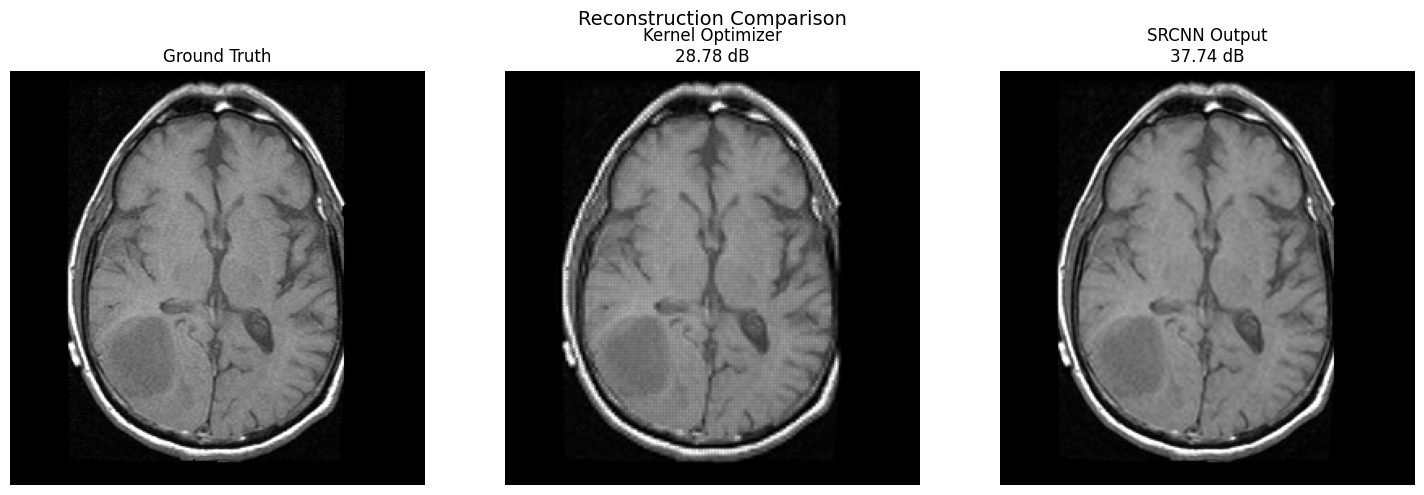

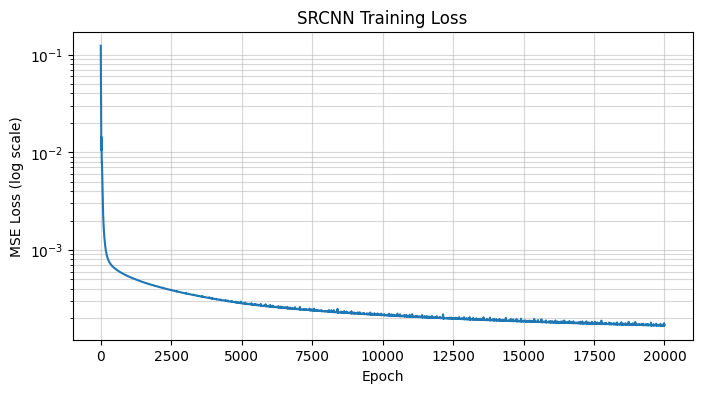

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(target_01.cpu().numpy(),      cmap='gray'); axes[0].set_title('Ground Truth');                 axes[0].axis('off')
axes[1].imshow(x_recon_norm.cpu().numpy(),   cmap='gray'); axes[1].set_title(f'Kernel Optimizer\n{psnr_before.item():.2f} dB'); axes[1].axis('off')
axes[2].imshow(sr_image.cpu().numpy(),       cmap='gray'); axes[2].set_title(f'SRCNN Output\n{psnr_after.item():.2f} dB');      axes[2].axis('off')

plt.suptitle('Reconstruction Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# SRCNN training loss
plt.figure(figsize=(8, 4))
plt.semilogy(srcnn_loss_history)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (log scale)')
plt.title('SRCNN Training Loss'); plt.grid(True, which='both', alpha=0.5)
plt.show()

In [ ]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

recon_4d  = final_x_recon.detach().clamp(0, 1).unsqueeze(0).unsqueeze(0).float()
target_4d = target_image.clamp(0, 1).unsqueeze(0).unsqueeze(0).float()
sr_4d     = sr_output.clamp(0, 1).float()

x_min, x_max = recon_4d.min(), recon_4d.max()
recon_4d_norm = (recon_4d - x_min) / (x_max - x_min + 1e-8)

ssim_kernel = ssim_metric(recon_4d_norm, target_4d)
ssim_sr     = ssim_metric(sr_4d,         target_4d)

print(f"PSNR before SRCNN (kernel optimizer output) : {psnr_before.item():.2f} dB")
print(f"PSNR after  SRCNN                           : {psnr_after.item():.2f} dB")
print(f"Improvement                                 : {(psnr_after - psnr_before).item():+.2f} dB")
print()
print(f"SSIM before SRCNN (kernel optimizer output) : {ssim_kernel.item():.4f}")
print(f"SSIM after  SRCNN                           : {ssim_sr.item():.4f}")
print(f"Improvement                                 : {(ssim_sr - ssim_kernel).item():+.4f}")

PSNR before SRCNN (kernel optimizer output) : 28.78 dB
PSNR after  SRCNN                           : 37.74 dB
Improvement                                 : +8.96 dB

SSIM before SRCNN (kernel optimizer output) : 0.8786
SSIM after  SRCNN                           : 0.9534
Improvement                                 : +0.0748
